# W11 阶段项目：无人机悬停的端到端训练与消融报告

> 阶段一（SB3 算法基础）· 第 11 周 · 阶段项目
> 前置：W01–W10 全部内容

## 项目说明

这是阶段一的**综合项目**：不再以「学新概念」为目标，而是把前十周的技能串成一条完整流水线——

**理解环境 → 建立无学习基线 → 训练两个算法 → 固定协议评估 → 泛化与消融实验 → 写消融报告**

完成本 notebook 后，你的交付物应包括：

1. 两个训练好的模型（PPO、SAC）及其评估数字；
2. 一张「算法 × 指标」对比表（含无学习基线）；
3. 至少两组消融实验及其结论；
4. 一份按模板填写的消融报告（最后一节）。

工作对象是本项目的自定义环境 `DroneHoverEnv`（`src/robot_rl_learn/phase1_sb3/envs.py`）——简化的一维无人机定高问题。

## 学习目标

1. 用「状态/动作/奖励/终止/初始分布」五要素法分析一个自定义环境，并通过 `check_env` 合规检查；
2. 为 RL 实验建立无学习基线（PD 控制器），理解基线在工程中的意义；
3. 复用项目封装的训练/评估/绘图 API，端到端完成两个算法的训练与对比；
4. 设计并执行消融实验（观测泛化、超参敏感性），按模板撰写消融报告。


## 1. 环境理解：先读懂，再训练

拿到任何环境，第一件事是**读文档/源码，回答五个问题**：状态是什么？动作是什么？奖励怎么算？何时终止？初始状态怎么采样？

`DroneHoverEnv` 的答案：

| 要素 | 内容 |
|------|------|
| 观测 $s$ | $[h - h^*, \; \dot{h}]$：高度误差 + 垂直速度，**注意是相对量** |
| 动作 $a$ | 归一化推力 $u \in [-1, 1]$，映射为加速度 $a = u \cdot g$ |
| 奖励 $r$ | $-\big[(h-h^*)^2 + 0.1\dot{h}^2 + 0.01u^2\big]$：误差、速度、能耗三项惩罚 |
| 终止 | $\lvert h-h^* \rvert > 3$ 提前失败；500 步截断 |
| 初始状态 | $h \sim U(0, 2)$，$\dot{h} \sim U(-0.5, 0.5)$ |

奖励全是非正的惩罚项，回报越接近 0 越好。理想悬停（误差和速度恒为 0、推力恒为 0）的理论回报上限是 0。

按 Gymnasium 规范注册环境并用 `check_env` 做合规检查（W02 的老朋友）：


In [1]:
# 本课程统一在 CPU 上训练：在导入任何深度学习库之前屏蔽 GPU。
# 同时限制线程数：小 MLP 策略网络用 4 线程足够，默认占满所有核反而
# 在多进程/高负载机器上因线程争抢急剧变慢（OMP spin-wait 问题）
import os

os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"


In [2]:
from contextlib import suppress

import gymnasium as gym
import numpy as np
from gymnasium.envs.registration import register
from stable_baselines3.common.env_checker import check_env

# 注册项目的自定义环境（重复注册会抛错，幂等处理）
with suppress(gym.error.Error):
    register(id="DroneHover-v0",
             entry_point="robot_rl_learn.phase1_sb3.envs:DroneHoverEnv")

check_env(gym.make("DroneHover-v0"), warn=False)
print("check_env 通过：环境符合 Gymnasium 规范")

# 手工 rollout 几步，直观感受奖励结构
env = gym.make("DroneHover-v0")
obs, _ = env.reset(seed=0)
print(f"初始观测 [高度误差, 垂直速度]: {obs}")
for _ in range(3):
    obs, r, term, trunc, _ = env.step(env.action_space.sample())
    print(f"随机动作后: obs={obs.round(3)}, r={r:.4f}, terminated={term}")


check_env 通过：环境符合 Gymnasium 规范
初始观测 [高度误差, 垂直速度]: [ 0.27392337 -0.23021328]
随机动作后: obs=[ 0.267 -0.366], r=-0.0893, terminated=False
随机动作后: obs=[ 0.257 -0.502], r=-0.0959, terminated=False
随机动作后: obs=[ 0.248 -0.435], r=-0.0815, terminated=False


## 2. 无学习基线：手写 PD 控制器

**任何 RL 项目都要先建立一个无学习基线**——它回答「这个问题真的需要学习吗」。对定高这种经典控制问题，PD 控制器是自然选择：

$$u = \text{clip}\big(-k_p (h - h^*) - k_d \dot{h},\; -1,\; 1\big)$$

这正是自动控制原理课的内容：比例项消除误差，微分项抑制振荡。注意本环境中 $u=0$ 对应「推力抵消重力」（悬停），所以控制器输出不需要额外的重力补偿项。


In [3]:
def pd_controller(obs: np.ndarray, kp: float = 1.5, kd: float = 0.8) -> np.ndarray:
    """PD 定高控制器：输入观测，输出归一化推力。"""
    height_err, velocity = obs
    u = -(kp * height_err + kd * velocity)
    return np.array([np.clip(u, -1.0, 1.0)], dtype=np.float32)


def rollout_with_policy(policy_fn, env_id="DroneHover-v0", n_episodes=20, **env_kwargs):
    """通用评估循环：policy_fn(obs) -> action，返回每个 episode 的回报列表。"""
    env = gym.make(env_id, **env_kwargs)
    returns = []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=100 + ep)
        done, total = False, 0.0
        while not done:
            obs, r, term, trunc, _ = env.step(policy_fn(obs))
            total += r
            done = term or trunc
        returns.append(total)
    env.close()
    return returns


pd_returns = rollout_with_policy(pd_controller)
print(f"PD 基线: {np.mean(pd_returns):.1f} ± {np.std(pd_returns):.1f} "
      f"(n={len(pd_returns)} episodes)")


PD 基线: -9.6 ± 5.6 (n=20 episodes)


> PD 基线约 -10 左右的回报就是 RL 要超越的门槛。如果 RL 训完还不如 PD，说明训练出了问题——基线的作用就是快速发现这一点。

## 3. 训练：PPO 与 SAC

用 W07 封装好的 `train()`（向量化环境 + EvalCallback 保存最优 + 检查点 + TensorBoard）。PPO 是 on-policy 代表，SAC 是 off-policy 代表，两者对比是连续控制的标准实验配置。


In [4]:
import time

import torch

from robot_rl_learn.common.paths import make_run_dir
from robot_rl_learn.phase1_sb3.train import evaluate, train

torch.set_num_threads(4)  # 与上面的环境变量配合，限制 CPU 线程数

# PPO：on-policy，60k 步（CPU 约 25s）
# 注意 n_steps=512：n_envs=4 时每次更新 batch = 512x4 = 2048，60k 步约 29 次更新；
# 若用默认 n_steps=2048，batch 变成 8192、只剩约 7 次更新——策略根本学不动
t0 = time.time()
ppo_model = train("PPO", "DroneHover-v0", total_timesteps=60_000, n_envs=4, n_steps=512,
                  seed=0, log_dir=make_run_dir("w11_ppo"), eval_freq=10_000)
print(f"PPO 训练耗时 {time.time() - t0:.0f}s")

# SAC：off-policy，30k 步（CPU 约 2 分钟，样本效率更高）
t0 = time.time()
sac_model = train("SAC", "DroneHover-v0", total_timesteps=30_000, n_envs=1,
                  seed=0, log_dir=make_run_dir("w11_sac"), eval_freq=5_000,
                  learning_starts=100)
print(f"SAC 训练耗时 {time.time() - t0:.0f}s")


/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/gymnasium/envs/registration.py:788: UserWarning: WARN: The environment is being initialised with render_mode='rgb_array' that is not in the possible render_modes ([]).
  logger.warn(


Eval num_timesteps=10000, episode_reward=-104.05 +/- 27.45
Episode length: 500.00 +/- 0.00
New best mean reward!


Eval num_timesteps=20000, episode_reward=-486.74 +/- 43.06
Episode length: 284.00 +/- 77.10


Eval num_timesteps=30000, episode_reward=-16.04 +/- 16.90
Episode length: 500.00 +/- 0.00
New best mean reward!


Eval num_timesteps=40000, episode_reward=-1.76 +/- 1.40
Episode length: 500.00 +/- 0.00
New best mean reward!


...

Eval num_timesteps=10000, episode_reward=-3.46 +/- 2.91
Episode length: 500.00 +/- 0.00
New best mean reward!


Eval num_timesteps=15000, episode_reward=-10.70 +/- 5.83
Episode length: 500.00 +/- 0.00


Eval num_timesteps=20000, episode_reward=-8.60 +/- 3.98
Episode length: 500.00 +/- 0.00


Eval num_timesteps=25000, episode_reward=-4.91 +/- 6.58
Episode length: 500.00 +/- 0.00


Eval num_timesteps=30000, episode_reward=-3.74 +/- 2.09
Episode length: 500.00 +/- 0.00
SAC 训练耗时 120s


In [5]:
# 固定评估协议：20 个 episode、确定性策略
import pandas as pd
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor

ppo_r, ppo_s = evaluate(ppo_model, "DroneHover-v0", n_episodes=20)
sac_r, sac_s = evaluate(sac_model, "DroneHover-v0", n_episodes=20)

summary = pd.DataFrame([
    {"方法": "PD 控制器(无学习)", "平均回报": np.mean(pd_returns), "标准差": np.std(pd_returns),
     "训练步数": 0},
    {"方法": "PPO (60k)", "平均回报": ppo_r, "标准差": ppo_s, "训练步数": 60_000},
    {"方法": "SAC (30k)", "平均回报": sac_r, "标准差": sac_s, "训练步数": 30_000},
]).round(2)
summary


/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/gymnasium/envs/registration.py:788: UserWarning: WARN: The environment is being initialised with render_mode='rgb_array' that is not in the possible render_modes ([]).
  logger.warn(


,方法,平均回报,标准差,训练步数
0,PD 控制器(无学习),-9.64,5.61,0
1,PPO (60k),-6.48,6.66,60000
2,SAC (30k),-7.32,5.36,30000


/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 22522 (\N{CJK UNIFIED IDEOGRAPH-57FA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


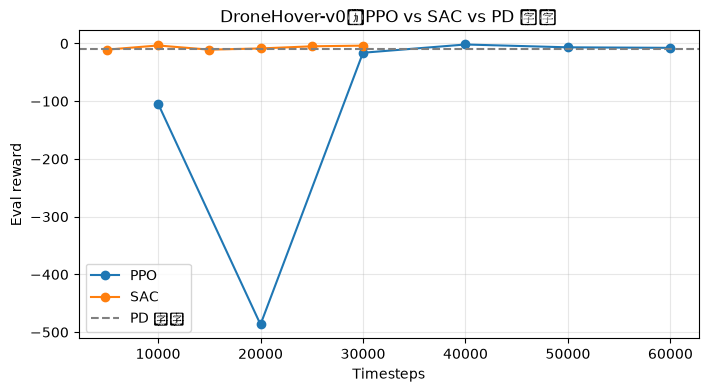

In [6]:
# 评估曲线对比（EvalCallback 记录，比训练曲线更可信）
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
for name, run in [("PPO", "w11_ppo"), ("SAC", "w11_sac")]:
    d = np.load(make_run_dir(run) / "eval" / "evaluations.npz")
    mean = d["results"].mean(axis=1)
    ax.plot(d["timesteps"], mean, marker="o", label=name)
ax.axhline(np.mean(pd_returns), color="gray", ls="--", label="PD 基线")
ax.set_xlabel("Timesteps")
ax.set_ylabel("Eval reward")
ax.set_title("DroneHover-v0：PPO vs SAC vs PD 基线")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


## 4. 消融实验一：观测设计带来的泛化

回顾第 1 节的表格：环境的观测是**高度误差** $h - h^*$ 而不是绝对高度 $h$。这意味着策略学到的其实是「误差 → 推力」的映射，与目标高度无关——理论上应该**零成本泛化**到别的目标高度。验证一下：


In [7]:
# 消融一：在训练时没见过的目标高度上评估（环境动力学不变，只换 target_height）
rows = []
for h in [0.5, 1.0, 1.5]:
    eval_env = Monitor(gym.make("DroneHover-v0", target_height=h))
    m_p, _ = evaluate_policy(ppo_model, eval_env, n_eval_episodes=10, deterministic=True)
    m_s, _ = evaluate_policy(sac_model, eval_env, n_eval_episodes=10, deterministic=True)
    rows.append({"target_height": h, "PPO": round(m_p, 2), "SAC": round(m_s, 2),
                 "训练时见过": h == 1.0})

pd.DataFrame(rows)


,target_height,PPO,SAC,训练时见过
0,0.5,-7.16,-13.21,False
1,1.0,-6.51,-5.01,True
2,1.5,-9.08,-27.05,False


> 分析要点：**如果**策略收敛得好，三个目标高度上的回报应大致接近——这不是 RL 的功劳，而是**状态表征设计**的功劳：把绝对高度换成相对误差，等于把「目标高度」从状态空间里消掉了。若实测有差距（尤其是训练预算不足的策略），说明学到的「误差 → 推力」映射本身还不够精确，泛化只是给了可能性，策略质量决定能否兑现。做机器人环境设计时，「相对量观测」是最便宜也最有效的泛化手段（阶段二的域随机化是另一条更贵的路）。

## 5. 消融实验二：超参敏感性

W08 说过超参是「隐形代码」。在项目里用一个超参做示范：PPO 的 `learning_rate` 提高一个数量级会发生什么？


In [8]:
# 消融二：learning_rate 3e-4(默认) vs 3e-3(10倍)
ablation_results = {}
for lr_tag, lr in [("lr=3e-4 (默认)", 3e-4), ("lr=3e-3 (10x)", 3e-3)]:
    model = train("PPO", "DroneHover-v0", total_timesteps=30_000, n_envs=4, n_steps=512,
                  seed=0, learning_rate=lr,
                  log_dir=make_run_dir(f"w11_ablation_{lr_tag.split('=')[1].split(' ')[0]}"),
                  eval_freq=10_000)
    m, s = evaluate(model, "DroneHover-v0", n_episodes=20)
    ablation_results[lr_tag] = (m, s)
    print(f"{lr_tag}: {m:.1f} ± {s:.1f}")


/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/gymnasium/envs/registration.py:788: UserWarning: WARN: The environment is being initialised with render_mode='rgb_array' that is not in the possible render_modes ([]).
  logger.warn(


Eval num_timesteps=10000, episode_reward=-82.15 +/- 66.29
Episode length: 500.00 +/- 0.00
New best mean reward!


Eval num_timesteps=20000, episode_reward=-487.90 +/- 28.95
Episode length: 281.80 +/- 49.81


Eval num_timesteps=30000, episode_reward=-13.93 +/- 8.25
Episode length: 500.00 +/- 0.00
New best mean reward!


lr=3e-4 (默认): -31.3 ± 14.4


Eval num_timesteps=10000, episode_reward=-19.61 +/- 3.52
Episode length: 500.00 +/- 0.00
New best mean reward!


Eval num_timesteps=20000, episode_reward=-7.71 +/- 7.55
Episode length: 500.00 +/- 0.00
New best mean reward!


Eval num_timesteps=30000, episode_reward=-3.14 +/- 2.55
Episode length: 500.00 +/- 0.00
New best mean reward!


lr=3e-3 (10x): -8.5 ± 7.2


## 6. 消融报告模板

把上面的实验按此模板整理成报告（这也是阶段一复盘 W12 要交的东西）：

---

### DroneHover 悬停策略训练 · 消融报告

**任务与环境**：一维无人机定高，观测 = [高度误差, 垂直速度]，动作 = 归一化推力。
**评估协议**：确定性策略，20 episodes，报告 平均回报 ± 标准差（回报为非正值，越接近 0 越好）。

**主结果**

| 方法 | 训练步数 | 平均回报 ± 标准差 | 备注 |
|------|---------|------------------|------|
| PD 基线 | 0 | （填入） | kp=1.5, kd=0.8 |
| PPO | 60k | （填入） | 默认超参 |
| SAC | 30k | （填入） | learning_starts=100 |

**消融 1：目标高度泛化**（改动：target_height ∈ {0.5, 1.0, 1.5}）

- 结果：（填入表格）
- 结论：相对量观测使策略对目标高度天然泛化。

**消融 2：学习率敏感性**（改动：learning_rate ×10）

- 结果：（填入）
- 结论：（填入：10 倍学习率下回报/方差如何变化？原因是什么？）

**已知局限**：（示例：训练未做多种子；未注入观测噪声；动力学无参数不确定性——这些留到阶段二 Sim2Real 解决）

---


## ✏️ 练习

### 练习 1（★，约 20 分钟）：最优模型 vs 最终模型
第 3 节评估的是 `final_model`。从 `runs/w11_ppo/best/best_model.zip` 加载 EvalCallback 保存的**历史最优模型**，与 final_model 用同一协议对比。
**可交付物**：两个数字 + 一句话：哪个更好？为什么 RL 训练要保留 best_model？

### 练习 2（★★，约 25 分钟）：种子方差
用 seed ∈ {0, 1, 2} 各训一个 PPO（15k 步即可），报告三个评估回报的均值与极差。
**可交付物**：3 行表格 + 2~3 句讨论：单种子实验结论有多可信？报告里应该怎样规范地报 RL 结果？

### 练习 3（★★，约 30 分钟）：奖励塑形消融
用 `gym.RewardWrapper` 写一个包装器，把奖励中的速度惩罚项 $0.1\dot{h}^2$ 去掉（提示：观测里有速度，可以在 wrapper 里重构奖励：$r' = r + 0.1\dot{h}^2$）。训练 PPO（15k 步）并与原始奖励对比。
**可交付物**：wrapper 代码 + 对比数字 + 结论：速度惩罚项在奖励塑形中起了什么作用（从「抑制振荡」角度分析）？

### 练习 4（★★★，约 40 分钟）：鲁棒性预实验（Sim2Real 预告）
写一个 `ObsNoiseWrapper` 给观测加高斯噪声 $\tilde{s} = s + \mathcal{N}(0, \sigma^2 I)$，取 $\sigma \in \{0, 0.05, 0.2\}$ 评估第 3 节训好的 PPO 策略，画出「噪声强度-回报」退化曲线。
**可交付物**：退化曲线图 + 3~5 句讨论：策略在哪个噪声水平开始明显退化？你能想到哪两种加固方法（提示：训练时加噪声 / 滤波）？这是阶段二 Sim2Real 的核心议题。


## 参考答案

### 练习 1

<details>
<summary>参考答案</summary>

```python
from stable_baselines3 import PPO
from robot_rl_learn.common.paths import RUNS_DIR

best = PPO.load(RUNS_DIR / "w11_ppo" / "best" / "best_model")
m_best, s_best = evaluate(best, "DroneHover-v0", n_episodes=20)
print(f"best_model: {m_best:.1f} ± {s_best:.1f}, final_model: {ppo_r:.1f} ± {ppo_s:.1f}")
```

要点：RL 训练不单调，回报冲高后回落很常见（策略更新破坏了好不容易学到的行为）。best_model 保存的是评估回报最高时刻的权重，部署时永远用 best 而不是 final。
</details>

### 练习 2

<details>
<summary>参考答案</summary>

```python
rows = []
for seed in [0, 1, 2]:
    m = train("PPO", "DroneHover-v0", total_timesteps=15_000, n_envs=4,
              seed=seed, log_dir=make_run_dir(f"w11_seed{seed}"), eval_freq=5_000)
    r, s = evaluate(m, "DroneHover-v0", n_episodes=20)
    rows.append((seed, round(r, 2), round(s, 2)))
print(rows)
```

讨论：RL 的种间方差可能很大（不同种子回报可差数倍），单种子结论不可信。规范做法：至少 3~5 个种子，报告均值 ± 标准差（或置信区间），比较算法时用配对检验。参考 Henderson et al. 2018《Deep Reinforcement Learning That Matters》。
</details>

### 练习 3

<details>
<summary>参考答案</summary>

```python
class NoVelPenaltyWrapper(gym.RewardWrapper):
    """去掉速度惩罚项：r' = r + 0.1 * v^2（原奖励中该项为 -0.1*v^2）。"""

    def reward(self, reward: float) -> float:
        velocity = self.env.unwrapped._velocity  # 教学演示：直接读内部状态
        return reward + 0.1 * velocity**2


def make_shaped_env():
    return NoVelPenaltyWrapper(gym.make("DroneHover-v0"))

# 用 register + entry_point 指向函数，或直接传 gym.Env 给 PPO
model = PPO("MlpPolicy", make_shaped_env(), seed=0, verbose=0)
model.learn(total_timesteps=15_000)
m, s = evaluate_policy(model, Monitor(gym.make("DroneHover-v0")),
                       n_eval_episodes=20, deterministic=True)
print(f"无速度惩罚: {m:.1f} ± {s:.1f}")
```

结论：去掉速度惩罚后，策略倾向于「猛推到位」——高度误差小但速度大，悬停点附近持续振荡，回报反而更差或方差更大。速度项是阻尼，等效于 PD 控制里的微分项：奖励塑形本质上是在编码先验的控制结构。
</details>

### 练习 4

<details>
<summary>参考答案</summary>

```python
class ObsNoiseWrapper(gym.ObservationWrapper):
    def __init__(self, env, sigma: float, seed: int = 0):
        super().__init__(env)
        self.sigma = sigma
        self.rng = np.random.default_rng(seed)

    def observation(self, obs):
        return obs + self.rng.normal(0, self.sigma, size=obs.shape).astype(np.float32)


sigmas = [0.0, 0.05, 0.2]
degrade = []
for sigma in sigmas:
    env = ObsNoiseWrapper(gym.make("DroneHover-v0"), sigma=sigma)
    m, s = evaluate_policy(ppo_model, env, n_eval_episodes=20, deterministic=True)
    degrade.append(m)
    print(f"sigma={sigma}: {m:.1f} ± {s:.1f}")

import matplotlib.pyplot as plt
plt.plot(sigmas, degrade, "o-")
plt.xlabel("观测噪声 sigma")
plt.ylabel("Eval reward")
plt.show()
```

讨论：噪声加大后回报明显退化（噪声通过策略网络直接转化为推力抖动）。两种加固思路：①训练时就注入观测噪声（鲁棒训练/域随机化思想，阶段二展开）；②在观测进入策略前加低通/卡尔曼滤波（信号处理思路）。两者可叠加。
</details>


## 延伸阅读

- [Henderson et al., Deep Reinforcement Learning That Matters (AAAI 2018)](https://arxiv.org/abs/1709.06560) —— RL 实验评估规范的经典论文，种子方差问题的出处
- [SB3 官方文档：Custom Environments](https://stable-baselines3.readthedocs.io/en/master/guide/custom_env.html) —— 自定义环境规范与 check_env
- [Gymnasium 官方教程](https://gymnasium.farama.org/) —— Wrapper、注册机制的官方参考
- [Tobin et al., Domain Randomization (IROS 2017)](https://arxiv.org/abs/1703.06907) —— 练习 4 的「加固思路」在阶段二的完整形态
- [Andrychowicz et al., What Matters in On-Policy RL (ICLR 2021)](https://arxiv.org/abs/2006.05990) —— 大规模消融研究的范本，写消融报告时参考其实验设计
